
Processing: Underexposed


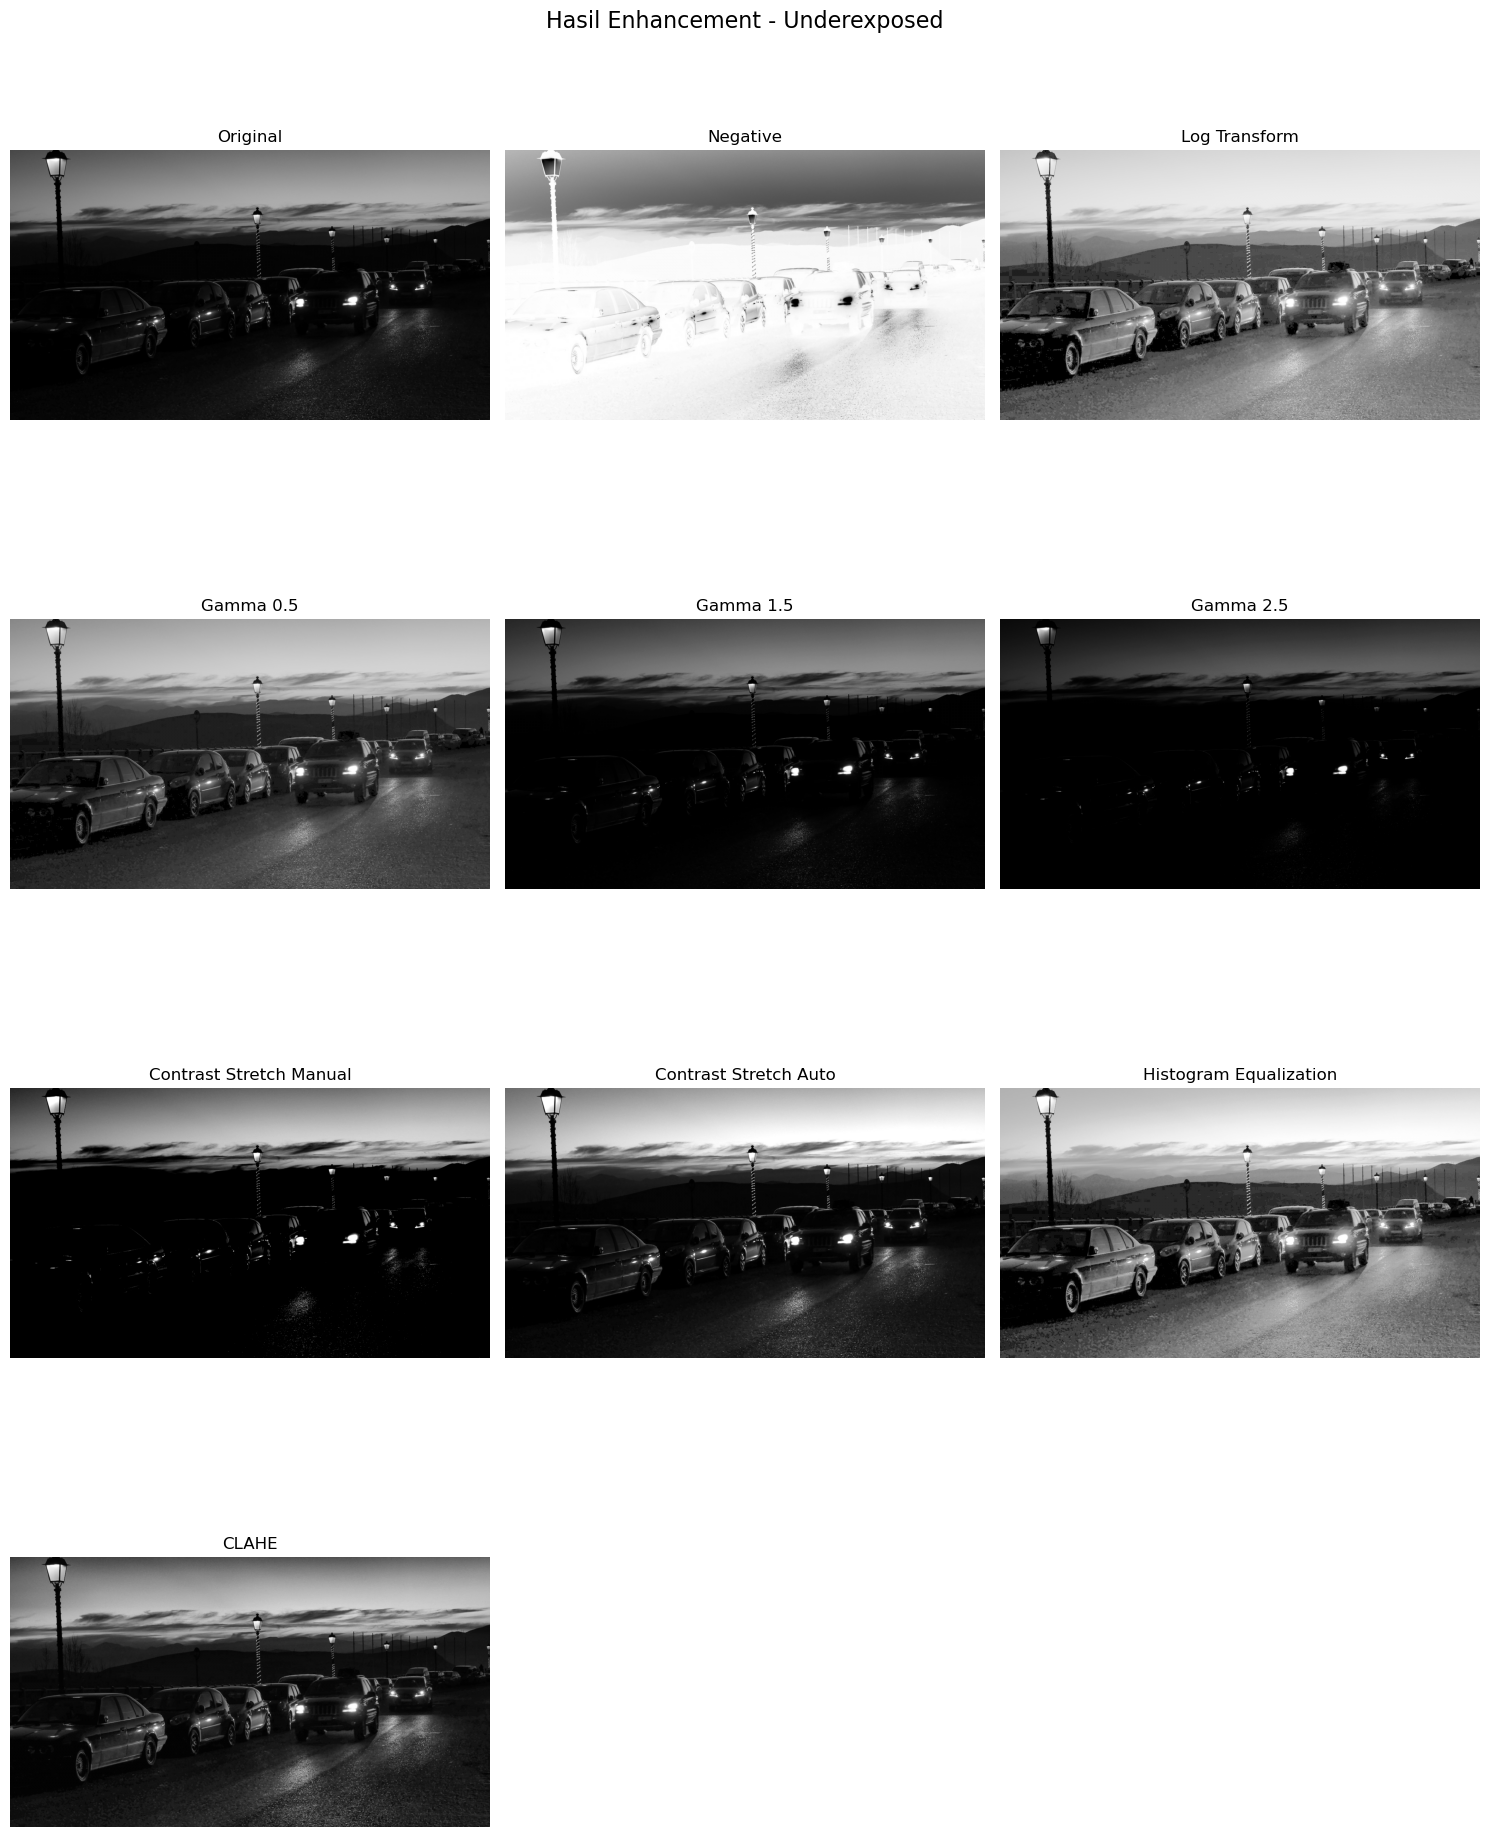

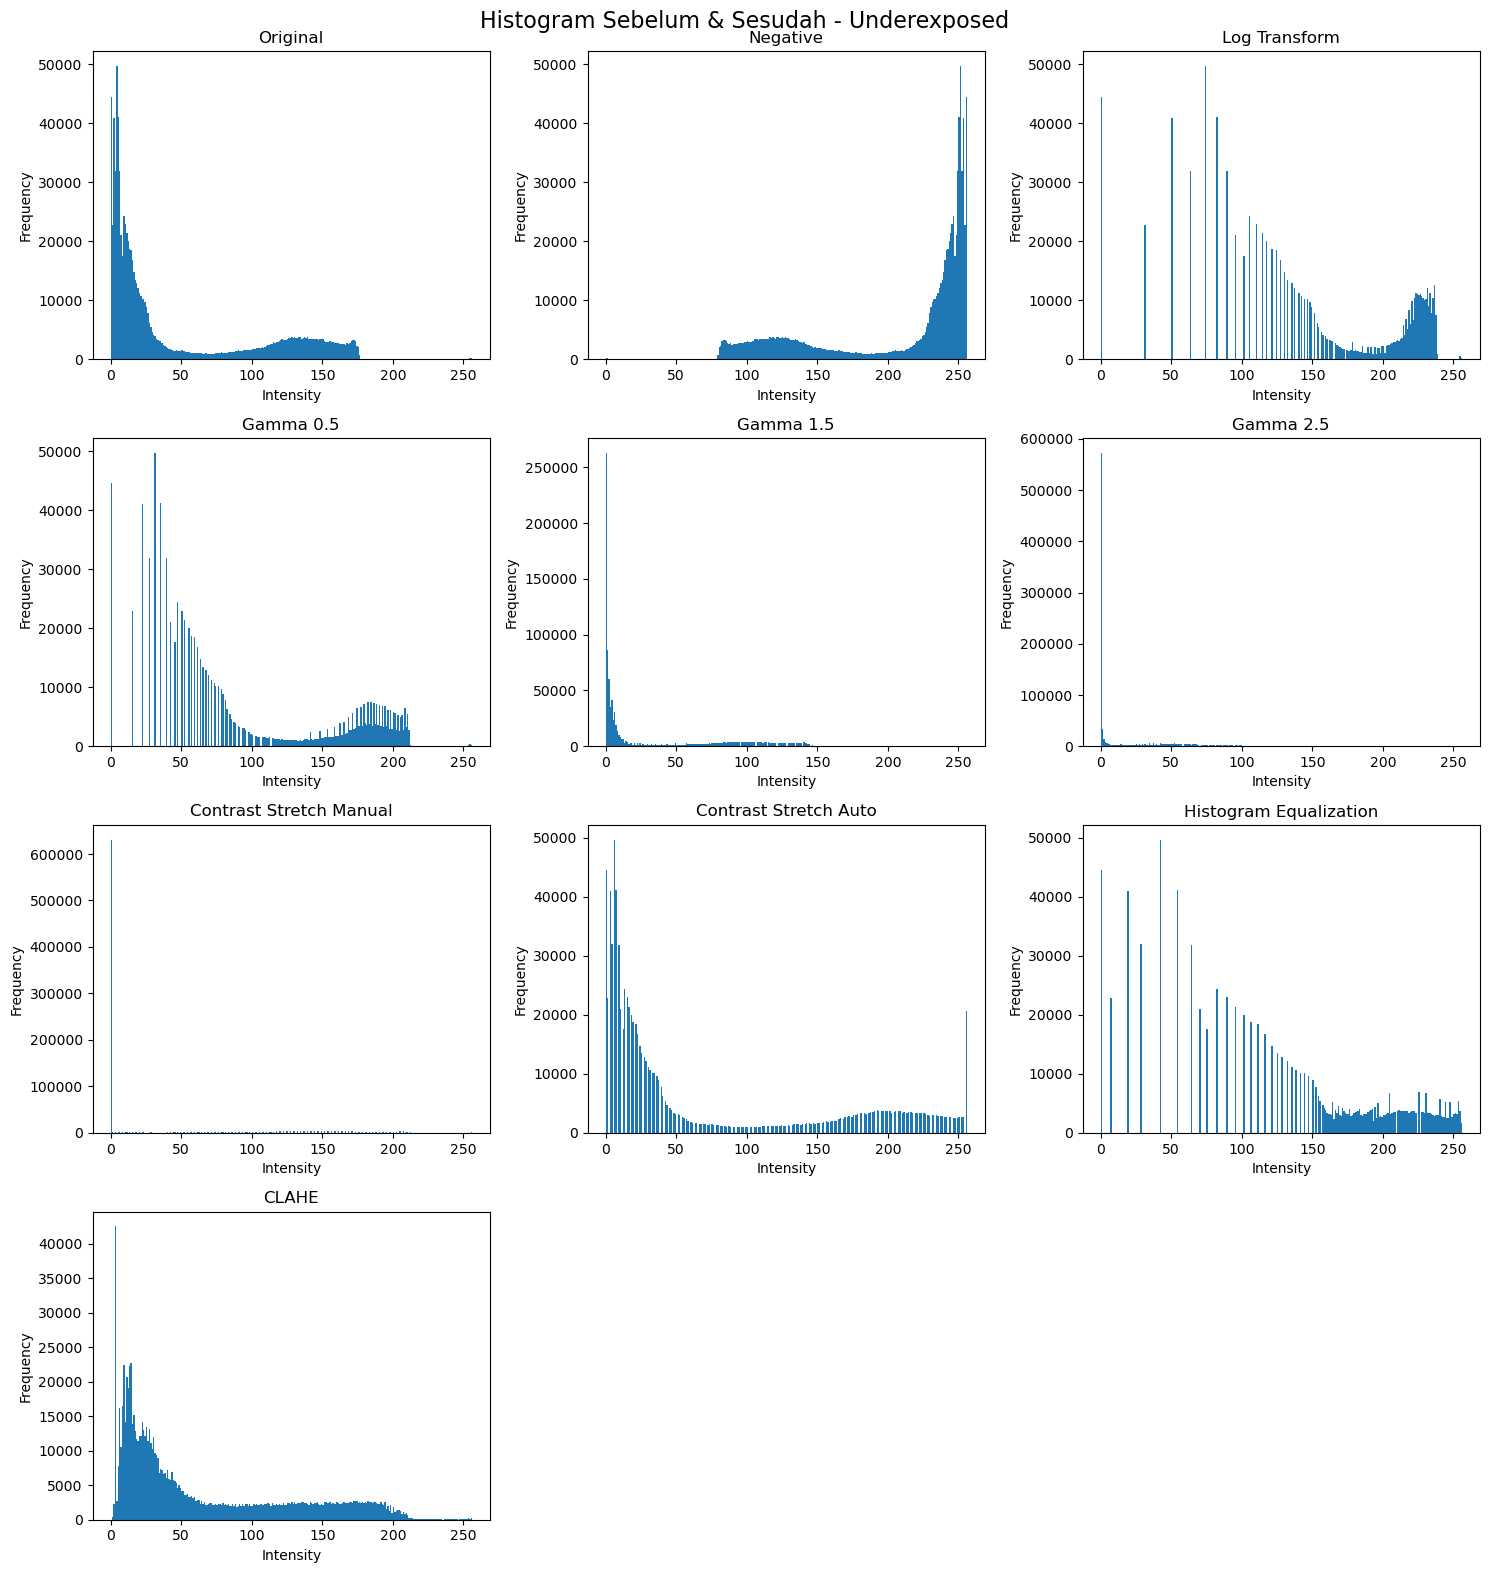


METRIK EVALUASI
---------------------------------------------------
Metode                         Contrast     Entropy      SNR         
Negative                       1.0000       6.5103       -8.3651     
Log Transform                  1.0000       6.0594       -2.0841     
Gamma 0.5                      1.0000       6.3416       4.6481      
Gamma 1.5                      1.0000       5.1283       10.5734     
Gamma 2.5                      1.0000       3.3386       4.2909      
Contrast Stretch Manual        1.0000       3.0632       12.2154     
Contrast Stretch Auto          1.0000       6.4277       6.1938      
Histogram Equalization         1.0000       6.2921       -0.9757     
CLAHE                          1.0000       7.1501       10.8334     

Processing: Overexposed


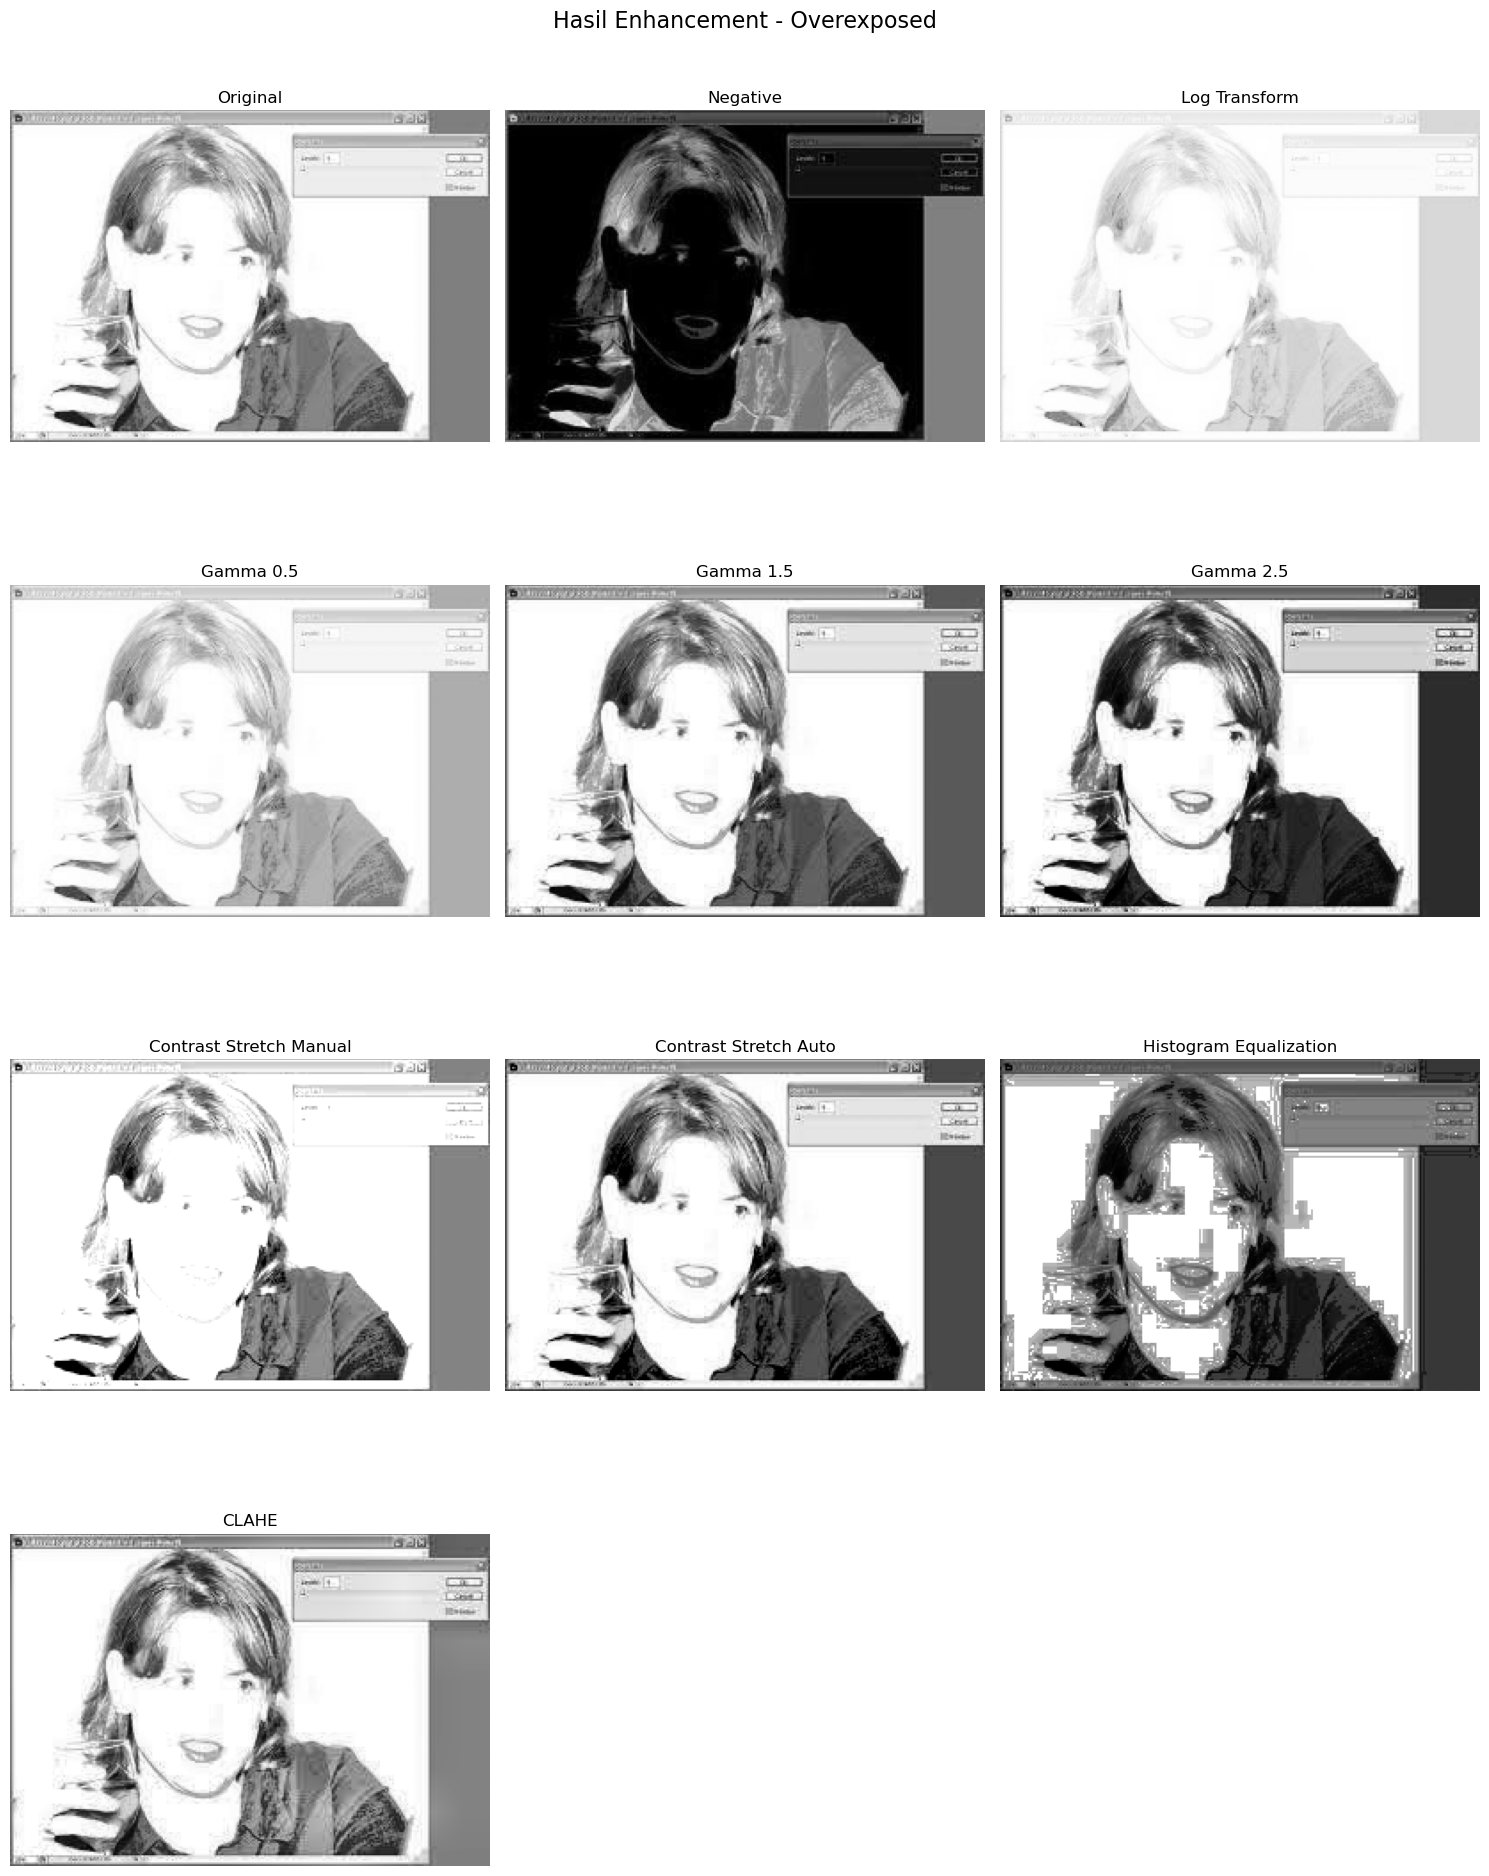

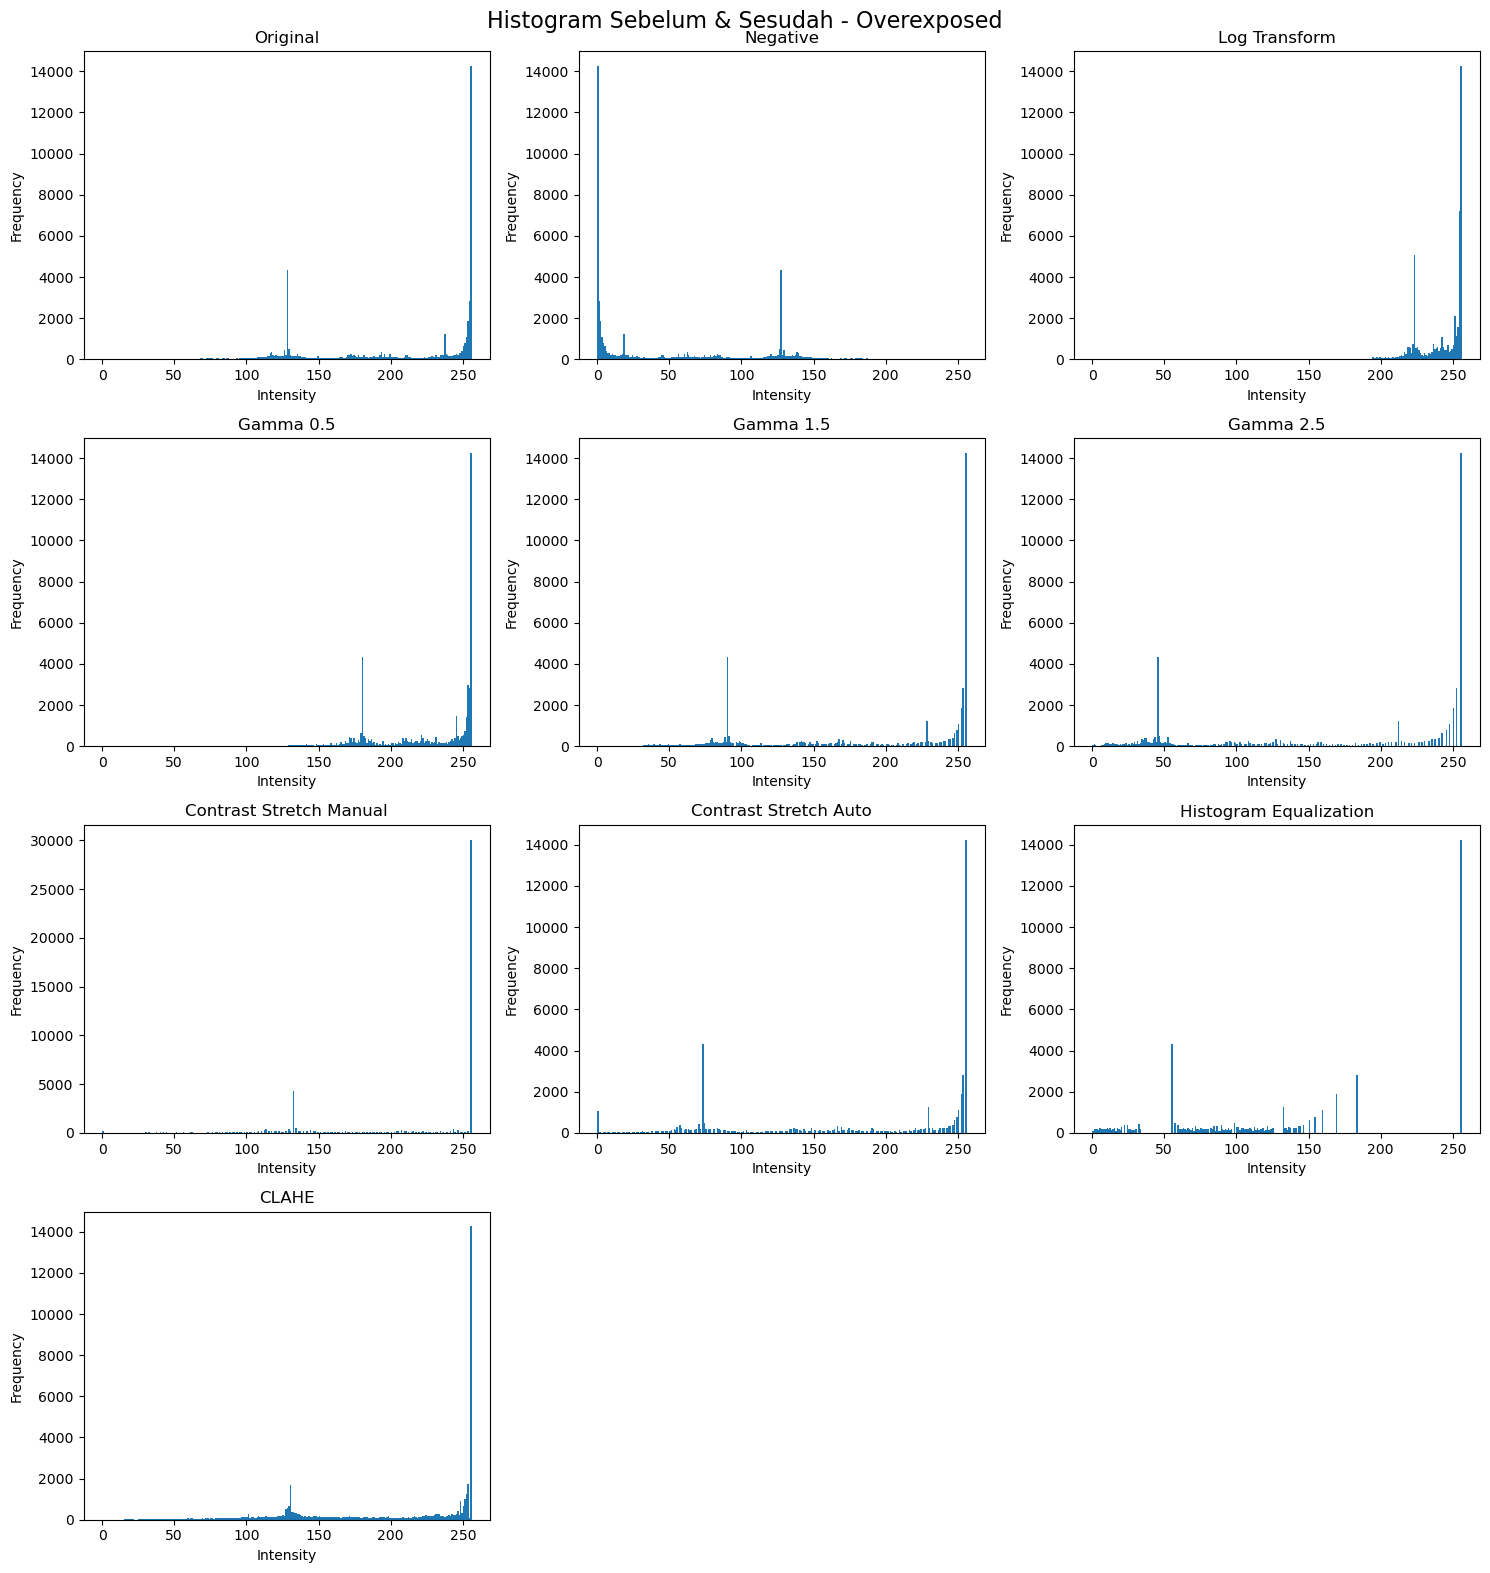


METRIK EVALUASI
---------------------------------------------------
Metode                         Contrast     Entropy      SNR         
Negative                       1.0000       5.5763       0.8476      
Log Transform                  0.6721       4.3677       11.2531     
Gamma 0.5                      0.8412       5.1538       16.5494     
Gamma 1.5                      1.0000       5.5599       19.3103     
Gamma 2.5                      1.0000       5.4724       12.2565     
Contrast Stretch Manual        1.0000       3.4516       20.4566     
Contrast Stretch Auto          1.0000       5.4664       16.0406     
Histogram Equalization         1.0000       5.2529       8.9199      
CLAHE                          0.9922       6.0697       21.3325     

Processing: Uneven Illumination


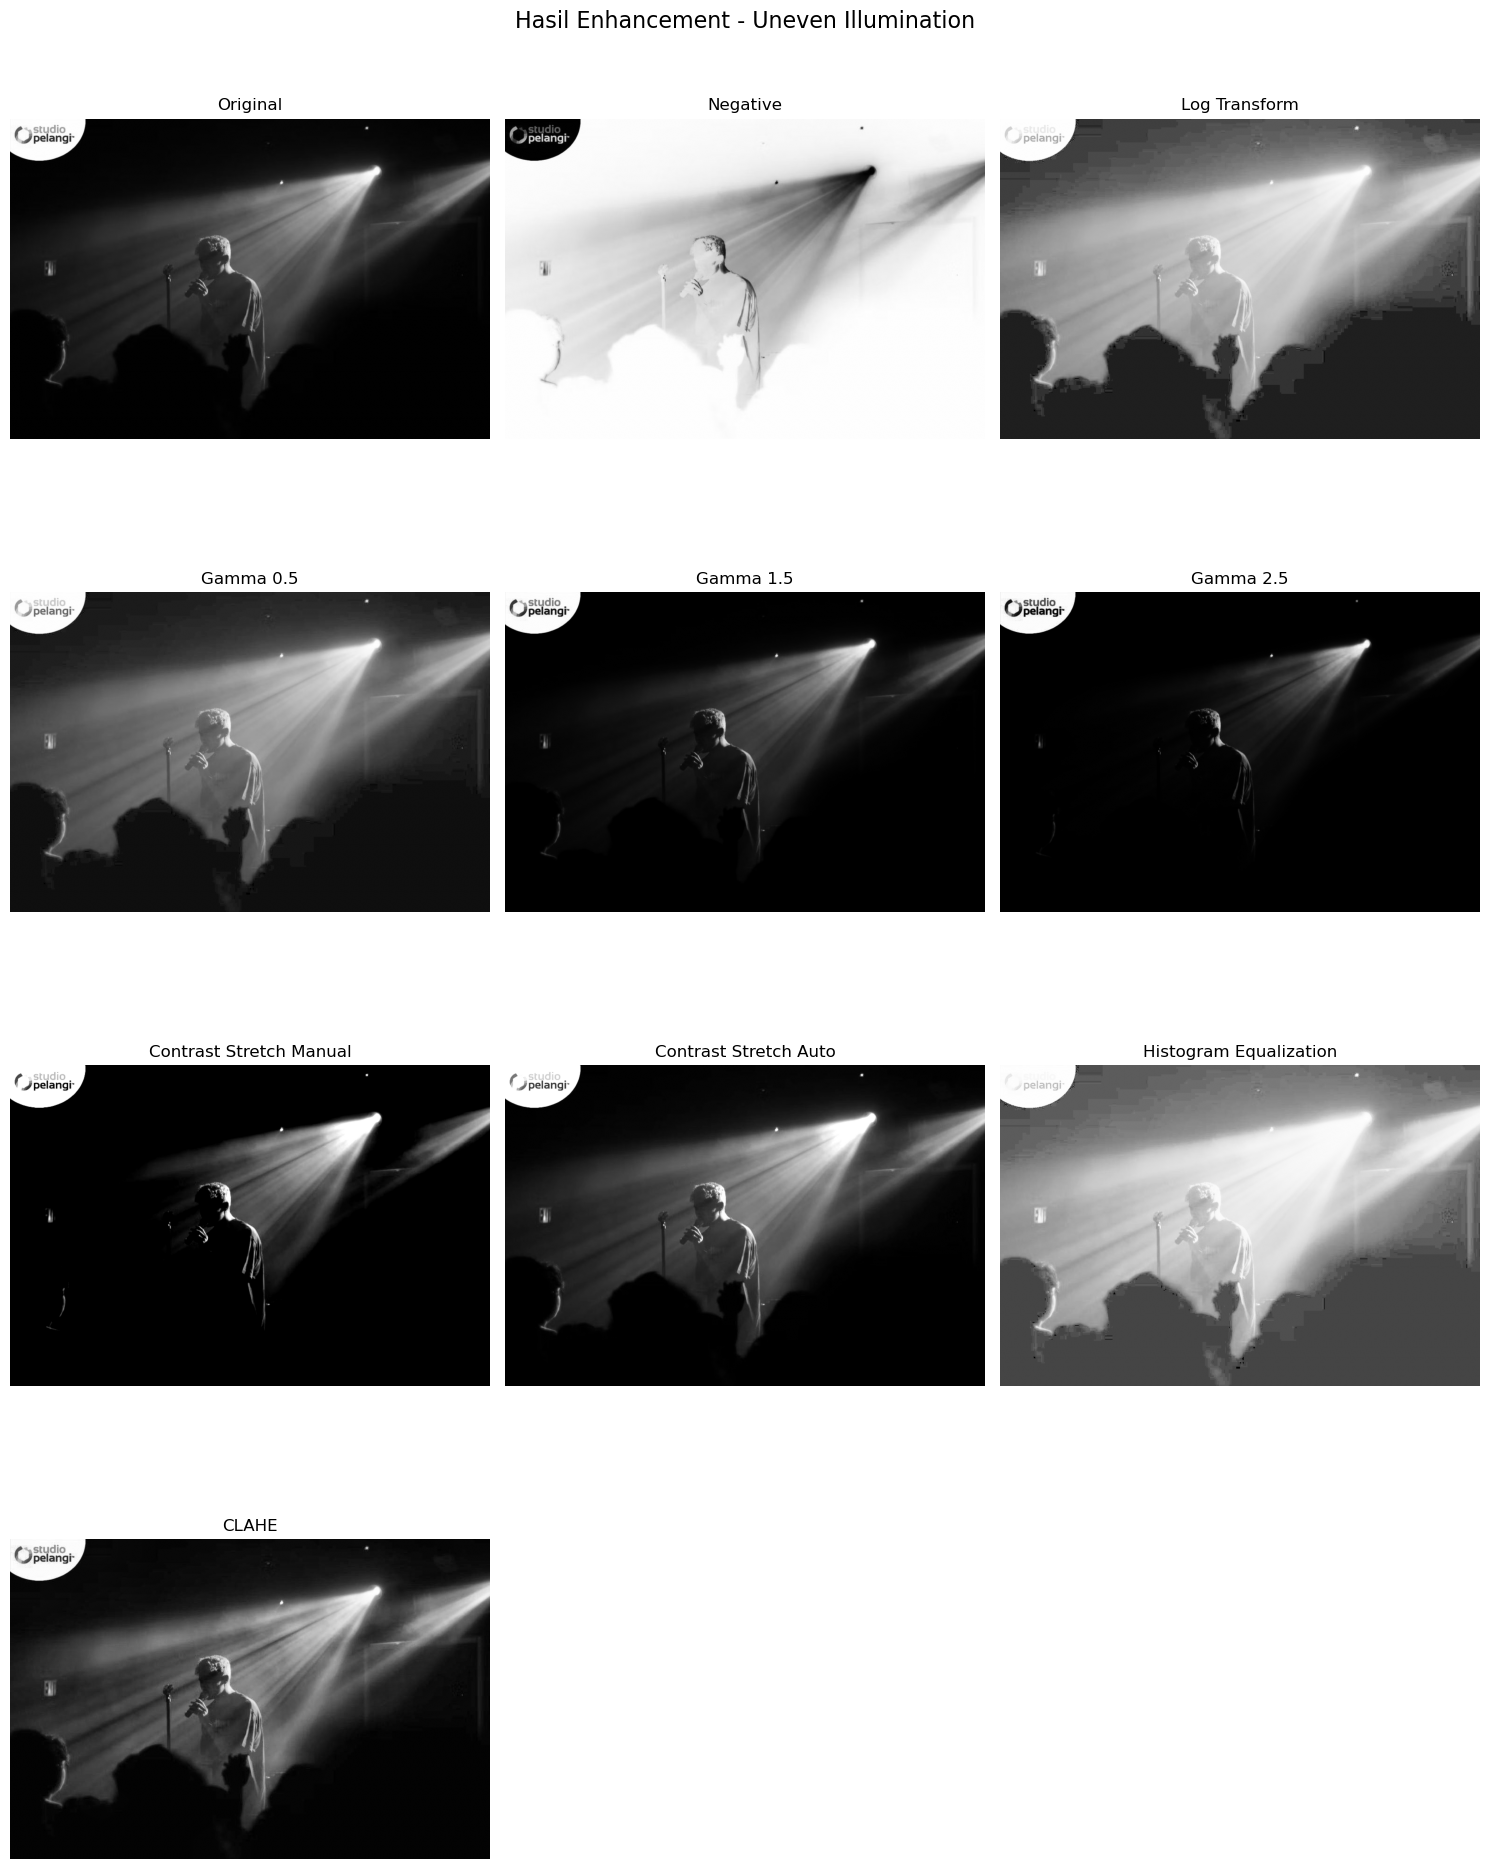

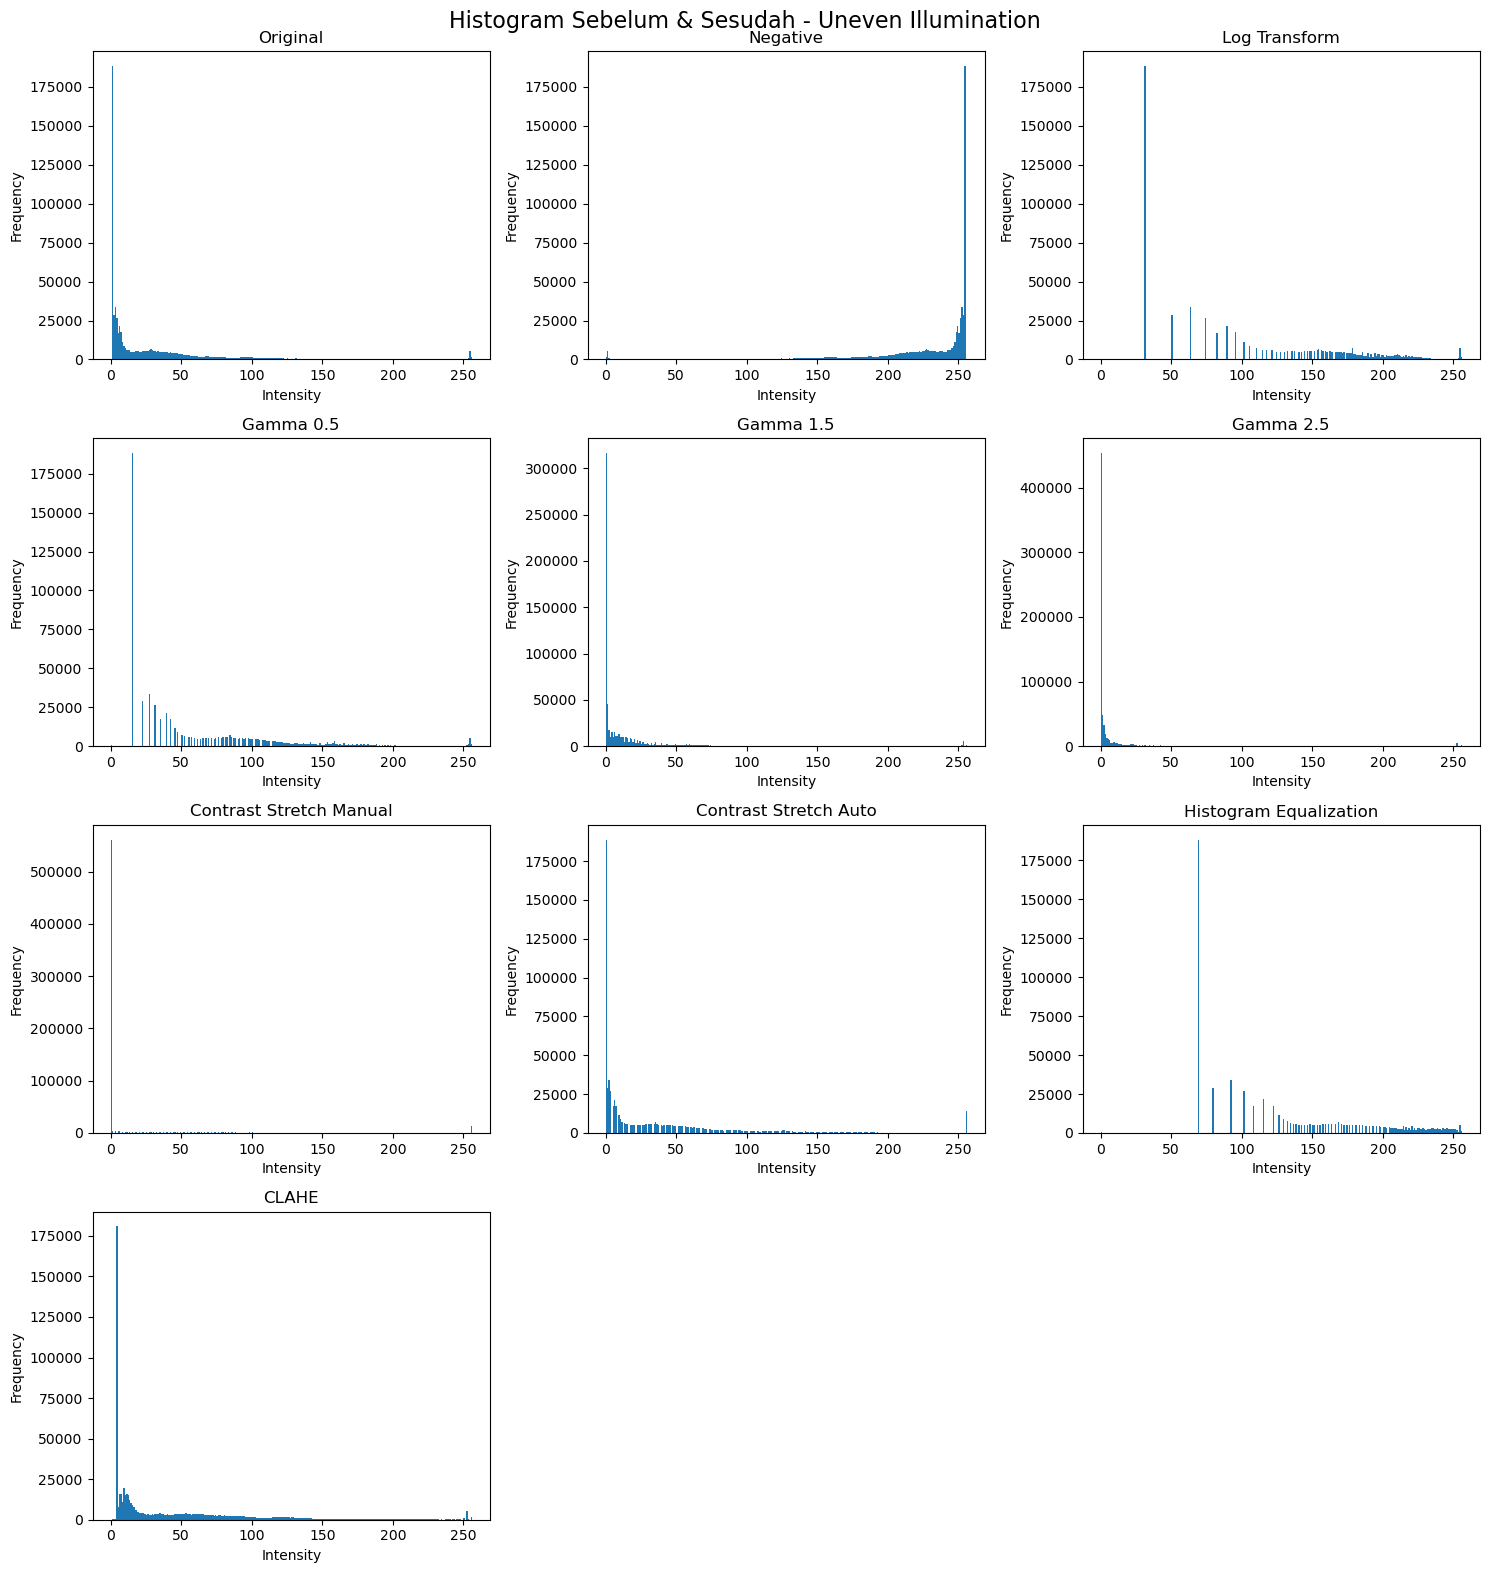


METRIK EVALUASI
---------------------------------------------------
Metode                         Contrast     Entropy      SNR         
Negative                       1.0000       5.6124       -11.7364    
Log Transform                  1.0000       5.4075       -4.3099     
Gamma 0.5                      1.0000       5.5557       2.4658      
Gamma 1.5                      1.0000       4.2690       9.6552      
Gamma 2.5                      1.0000       2.6988       4.5411      
Contrast Stretch Manual        1.0000       1.9953       8.1175      
Contrast Stretch Auto          1.0000       5.5218       12.7458     
Histogram Equalization         1.0000       5.3564       -6.1670     
CLAHE                          0.9922       6.0607       8.6129      


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure
from math import log10

# ==========================================================
# UTILITAS DASAR
# ==========================================================

def read_image_gray(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Gagal membaca file: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img


def show_image_grid(images_dict, title):
    n = len(images_dict)
    cols = 3
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(15, 5 * rows))
    plt.suptitle(title, fontsize=16)

    for i, (name, img) in enumerate(images_dict.items()):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(name)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


def show_histogram_grid(images_dict, title):
    n = len(images_dict)
    cols = 3
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(15, 4 * rows))
    plt.suptitle(title, fontsize=16)

    for i, (name, img) in enumerate(images_dict.items()):
        plt.subplot(rows, cols, i + 1)
        plt.hist(img.ravel(), bins=256, range=[0,256])
        plt.title(name)
        plt.xlabel("Intensity")
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ==========================================================
# POINT PROCESSING (SAFE FLOAT IMPLEMENTATION)
# ==========================================================

def negative_transform(img):
    return 255 - img


def log_transform(img):
    img_float = img.astype(np.float32)
    max_val = np.max(img_float)

    if max_val == 0:
        return img.copy()

    c = 255 / np.log(1 + max_val)
    log_img = c * np.log(1 + img_float)

    log_img = np.clip(log_img, 0, 255)
    return log_img.astype(np.uint8)


def gamma_transform(img, gamma):
    img_float = img.astype(np.float32) / 255.0
    gamma_img = np.power(img_float, gamma)
    gamma_img = gamma_img * 255
    gamma_img = np.clip(gamma_img, 0, 255)
    return gamma_img.astype(np.uint8)


# ==========================================================
# HISTOGRAM-BASED ENHANCEMENT
# ==========================================================

def contrast_stretch_manual(img, r1=50, r2=200):
    img_float = img.astype(np.float32)

    s1, s2 = 0, 255
    result = np.zeros_like(img_float)

    mask1 = img_float < r1
    mask2 = (img_float >= r1) & (img_float <= r2)
    mask3 = img_float > r2

    result[mask1] = (s1 / r1) * img_float[mask1]
    result[mask2] = ((s2 - s1) / (r2 - r1)) * (img_float[mask2] - r1) + s1
    result[mask3] = ((255 - s2) / (255 - r2)) * (img_float[mask3] - r2) + s2

    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)


def contrast_stretch_auto(img):
    p2, p98 = np.percentile(img, (2, 98))
    img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
    return img_rescale.astype(np.uint8)


def histogram_equalization(img):
    return cv2.equalizeHist(img)


def clahe_equalization(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(img)


# ==========================================================
# METRIK EVALUASI
# ==========================================================

def contrast_ratio(img):
    img_float = img.astype(np.float32)
    return (np.max(img_float) - np.min(img_float)) / \
           (np.max(img_float) + np.min(img_float) + 1e-8)


def entropy_measure(img):
    hist, _ = np.histogram(img.flatten(), 256, [0,256])
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist))


def snr(original, enhanced):
    original = original.astype(np.float32)
    enhanced = enhanced.astype(np.float32)

    noise = original - enhanced
    signal_power = np.mean(original**2)
    noise_power = np.mean(noise**2)

    if noise_power == 0:
        return np.inf

    return 10 * log10(signal_power / noise_power)


# ==========================================================
# PIPELINE PROSES PER CITRA
# ==========================================================

def process_image(path, label):

    print("\n===================================================")
    print(f"Processing: {label}")
    print("===================================================")

    img = read_image_gray(path)

    # POINT PROCESSING
    neg = negative_transform(img)
    log_img = log_transform(img)
    gamma1 = gamma_transform(img, 0.5)
    gamma2 = gamma_transform(img, 1.5)
    gamma3 = gamma_transform(img, 2.5)

    # HISTOGRAM-BASED
    cs_manual = contrast_stretch_manual(img)
    cs_auto = contrast_stretch_auto(img)
    he = histogram_equalization(img)
    clahe = clahe_equalization(img)

    results = {
        "Original": img,
        "Negative": neg,
        "Log Transform": log_img,
        "Gamma 0.5": gamma1,
        "Gamma 1.5": gamma2,
        "Gamma 2.5": gamma3,
        "Contrast Stretch Manual": cs_manual,
        "Contrast Stretch Auto": cs_auto,
        "Histogram Equalization": he,
        "CLAHE": clahe
    }

    # Tampilkan grid gambar
    show_image_grid(results, f"Hasil Enhancement - {label}")

    # Tampilkan grid histogram (SEBELUM & SESUDAH)
    show_histogram_grid(results, f"Histogram Sebelum & Sesudah - {label}")

    # Evaluasi metrik
    print("\nMETRIK EVALUASI")
    print("---------------------------------------------------")
    print("{:<30} {:<12} {:<12} {:<12}".format(
        "Metode", "Contrast", "Entropy", "SNR"))

    for name, result in results.items():
        if name == "Original":
            continue

        cr = contrast_ratio(result)
        ent = entropy_measure(result)
        snr_val = snr(img, result)

        print("{:<30} {:<12.4f} {:<12.4f} {:<12.4f}".format(
            name, cr, ent, snr_val))



process_image("under.jpg", "Underexposed")
process_image("over.jpeg", "Overexposed")
process_image("uneven.jpg", "Uneven Illumination")